# 04 — Random Walk
**Week 2 | Mathematical Foundations for RL**

Random walks appear everywhere in RL — from the way an agent explores to the theoretical analysis
of TD learning. They also give great intuition about variance in stochastic processes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(7)

## 1. Simple 1D Random Walk
At each step: move +1 (right) or -1 (left) with equal probability.

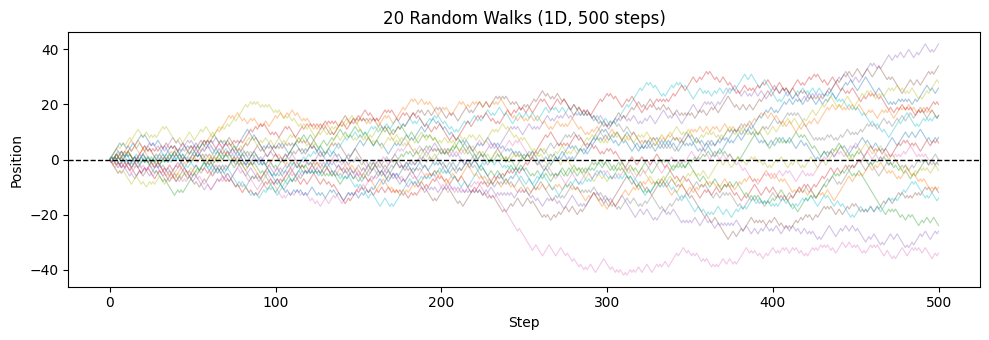

In [2]:
def random_walk_1d(n_steps, p_right=0.5):
    steps = np.where(np.random.rand(n_steps) < p_right, 1, -1)
    return np.concatenate([[0], np.cumsum(steps)])

n_steps = 500
fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(20):
    walk = random_walk_1d(n_steps)
    ax.plot(walk, alpha=0.4, linewidth=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Position')
ax.set_title('20 Random Walks (1D, 500 steps)')
plt.tight_layout(); plt.show()

## 2. Distribution of Positions at Time t
At time t, position X_t ~ N(0, t) — variance grows linearly with time.

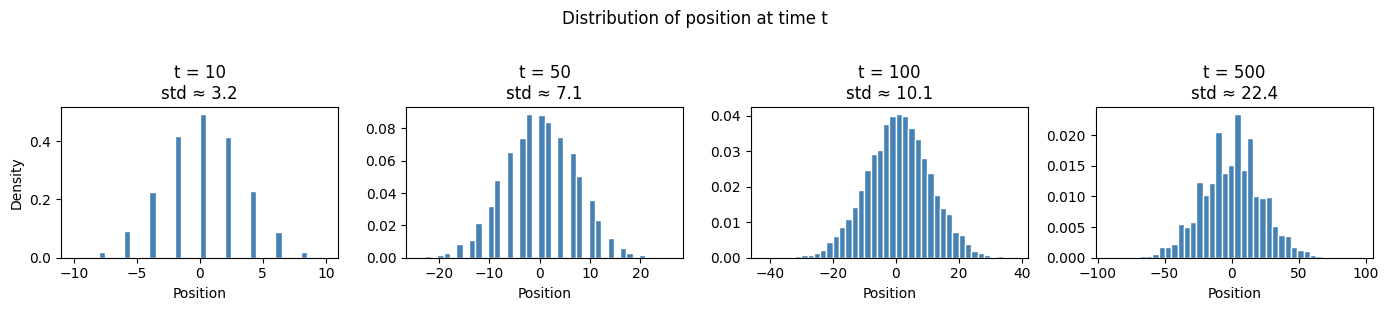

Theoretical std = sqrt(t): ['10→3.2', '50→7.1', '100→10.0', '500→22.4']


In [3]:
checkpoints = [10, 50, 100, 500]
n_walks = 10_000
fig, axes = plt.subplots(1, len(checkpoints), figsize=(14, 3), sharey=False)

for ax, t in zip(axes, checkpoints):
    positions = [random_walk_1d(t)[-1] for _ in range(n_walks)]
    ax.hist(positions, bins=40, color='steelblue', edgecolor='white', density=True)
    ax.set_title(f't = {t}\nstd ≈ {np.std(positions):.1f}')
    ax.set_xlabel('Position')

axes[0].set_ylabel('Density')
plt.suptitle('Distribution of position at time t', y=1.02)
plt.tight_layout(); plt.show()
print("Theoretical std = sqrt(t):", [f"{t}→{t**0.5:.1f}" for t in checkpoints])

## 3. Biased Random Walk
What if the agent has a preference? (p_right > 0.5)

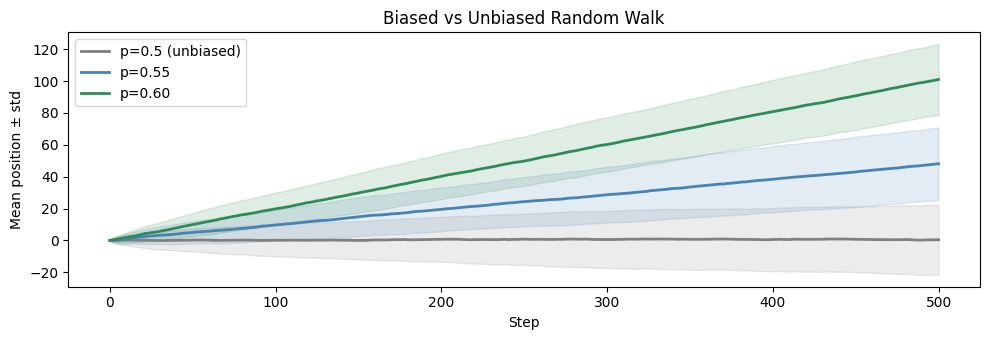

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for p, color, label in [(0.5,'gray','p=0.5 (unbiased)'), (0.55,'steelblue','p=0.55'), (0.6,'seagreen','p=0.60')]:
    walks = np.array([random_walk_1d(500, p) for _ in range(500)])
    mean_walk = walks.mean(axis=0)
    std_walk  = walks.std(axis=0)
    x = np.arange(501)
    ax.plot(mean_walk, color=color, linewidth=2, label=label)
    ax.fill_between(x, mean_walk-std_walk, mean_walk+std_walk, alpha=0.15, color=color)
ax.set_xlabel('Step'); ax.set_ylabel('Mean position ± std')
ax.set_title('Biased vs Unbiased Random Walk')
ax.legend(); plt.tight_layout(); plt.show()

## 4. First Passage Time
How long until the walk reaches position +10 for the first time?

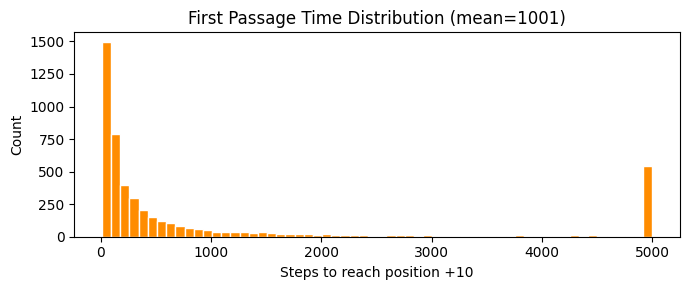

In [5]:
def first_passage_time(target=10, max_steps=5000):
    pos = 0
    for t in range(1, max_steps+1):
        pos += np.random.choice([-1, 1])
        if pos >= target:
            return t
    return max_steps  # didn't reach target

fpt = [first_passage_time(10) for _ in range(5000)]
plt.figure(figsize=(7, 3))
plt.hist(fpt, bins=60, color='darkorange', edgecolor='white')
plt.xlabel('Steps to reach position +10'); plt.ylabel('Count')
plt.title(f'First Passage Time Distribution (mean={np.mean(fpt):.0f})')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Modify the 1D walk to stop when it hits +20 or -20. What fraction of walks end at +20 vs -20?
2. Simulate a **2D random walk** (move up/down/left/right). Plot 5 trajectories on an x-y grid.
3. **Challenge**: implement the classic '5-state random walk' from Sutton & Barto Example 6.2. States A–E, terminal states at each end. Compute true state values analytically and verify empirically.

## Question 1.

In [6]:
def random_walk_absorbing(boundary=20, max_steps=100_000):
    pos = 0
    for t in range(max_steps):
        pos += np.random.choice([-1, 1])
        if abs(pos) >= boundary:
            return pos  
    return pos  

n_trials = 5000
outcomes = [random_walk_absorbing(20) for _ in range(n_trials)]
outcomes = np.array(outcomes)

frac_plus20 = np.mean(outcomes == 20)
frac_minus20 = np.mean(outcomes == -20)

print(f"Fraction ending at +20: {frac_plus20:.4f}")
print(f"Fraction ending at -20: {frac_minus20:.4f}")

Fraction ending at +20: 0.5080
Fraction ending at -20: 0.4920


## Question 2.

In [8]:
def random_walk_2d(n_steps):
    moves = np.array([[0,1],[0,-1],[-1,0],[1,0]])
    steps = moves[np.random.randint(0, 4, size=n_steps)]
    return np.concatenate([[[0,0]], np.cumsum(steps, axis=0)])

n_steps = 500
paths = [random_walk_2d(n_steps) for _ in range(5)]

for i, p in enumerate(paths):
    print(f"Walk {i}: start={p[0]}, end={p[-1]}, total steps={len(p)-1}")

Walk 0: start=[0 0], end=[  3 -31], total steps=500
Walk 1: start=[0 0], end=[-8 26], total steps=500
Walk 2: start=[0 0], end=[11 41], total steps=500
Walk 3: start=[0 0], end=[ -9 -17], total steps=500
Walk 4: start=[0 0], end=[15 15], total steps=500


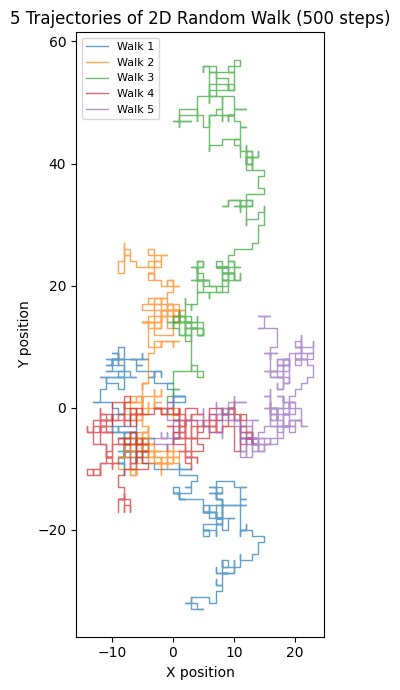

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
for i, path in enumerate(paths):
    ax.plot(path[:,0], path[:,1], alpha=0.7, linewidth=1, label=f'Walk {i+1}')

ax.set_xlabel('X position'); ax.set_ylabel('Y position')
ax.set_title('5 Trajectories of 2D Random Walk (500 steps)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Question 3.


In [11]:
def run_episode_5state():
    pos = 3   
    visited = [pos]
    while True:
        pos += np.random.choice([-1, 1])
        visited.append(pos)
        if pos == 0:
            return visited, 0.0
        if pos == 6:
            return visited, 1.0

n_episodes = 50_000
returns_per_state = {1: [], 2: [], 3: [], 4: [], 5: []}  # A,B,C,D,E

for _ in range(n_episodes):
    visited, final_reward = run_episode_5state()
    for s in set(visited):
        if s in returns_per_state:
            returns_per_state[s].append(final_reward)

print("Episodes run:", n_episodes)
print("Visits to state C (index 3):", len(returns_per_state[3]))

Episodes run: 50000
Visits to state C (index 3): 50000


State Analytical  Empirical   
A     0.1667      0.1670      
B     0.3333      0.3364      
C     0.5000      0.5028      
D     0.6667      0.6666      
E     0.8333      0.8337      


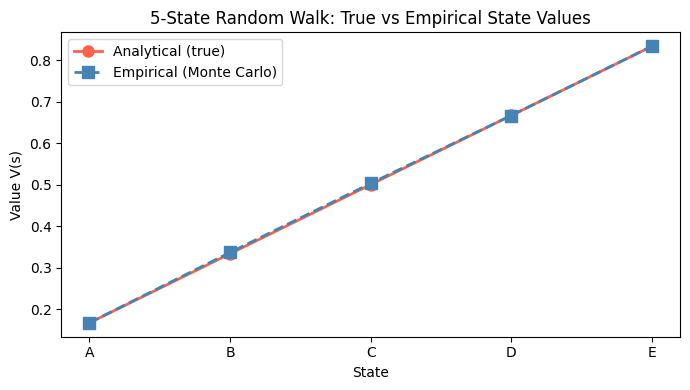

In [12]:
state_names = ['A','B','C','D','E']
analytical = [1/6, 2/6, 3/6, 4/6, 5/6]
empirical = [np.mean(returns_per_state[s]) for s in [1,2,3,4,5]]

print(f"{'State':<6}{'Analytical':<12}{'Empirical':<12}")
for name, a, e in zip(state_names, analytical, empirical):
    print(f"{name:<6}{a:<12.4f}{e:<12.4f}")

plt.figure(figsize=(7, 4))
plt.plot(state_names, analytical, 'o-', color='tomato', linewidth=2, markersize=8, label='Analytical (true)')
plt.plot(state_names, empirical, 's--', color='steelblue', linewidth=2, markersize=8, label='Empirical (Monte Carlo)')
plt.xlabel('State'); plt.ylabel('Value V(s)')
plt.title('5-State Random Walk: True vs Empirical State Values')
plt.legend(); plt.tight_layout(); plt.show()